# F4 — How much debt can the deal support?

A loan must fit the cash available to repay it. This lesson starts with an operating cash schedule, allows a margin for weaker performance, and calculates the loan size that the resulting payments can support.

Read F1 and F3 first. Our business rents computer time and sells it to customers. It does **not** own the computers. There is no hardware to sell at the end.

All amounts and lending rules here are **hypothetical**. Each month for 12 months, customers pay USD 20,000 and the supplier gets USD 12,000. That leaves USD 8,000 for loan payments. We leave taxes and other costs out of this small example.

A loan payment includes money borrowed (**principal**) and the charge for borrowing (**interest**). We require cash of at least USD 1.25 for each USD 1 of loan payment. The ratio of available cash to the required loan payment is the **debt-service coverage ratio**, or DSCR. Our minimum of 1.25 is an illustrative lending requirement, not an actual loan offer.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.financing import (
    build_amortizing_loan_schedule,
    debt_service_coverage,
    level_payment_debt_capacity_usd,
    shape_debt_service,
)
from liquid_compute.offtake import (
    OfftakeTerms,
    build_offtake_receipts,
    cash_available_for_debt_service_usd,
)

receipts = build_offtake_receipts(OfftakeTerms(20_000, 12))
cfads = cash_available_for_debt_service_usd(
    [r.receipts_usd for r in receipts], [0] + [12_000] * 12
)[1:]
minimum_dscr = 1.25
nominal_annual_interest_rate = 0.12

## First, find a payment we can afford

USD 8,000 divided by 1.25 gives a maximum monthly loan payment of USD 6,400. If cash changes from month to month, the weakest month limits a loan with equal payments.

Next, find how much borrowing those payments can repay. We use F1's loan calculation. The annual loan rate divided by 12 gives our monthly interest rate. This is a stated rule for this example; it differs from Notebook 2's annual present-value rate.

The first payment is in month 1. There are 12 payments, no fees and no payment holiday. The last payment must clear the debt. Borrowed money is cash received, but it is not sales revenue.

In [3]:
monthly_rate = nominal_annual_interest_rate / 12
allowed_payment_usd = min(cfads) / minimum_dscr
manual_capacity_usd = (
    allowed_payment_usd * (1 - (1 + monthly_rate) ** -12) / monthly_rate
)
print(f"Allowed payment: USD {allowed_payment_usd:,.2f}")
print(f"Coverage: {8_000 / allowed_payment_usd:.2f}x")
print(f"Initial debt capacity: USD {manual_capacity_usd:,.2f}")

Allowed payment: USD 6,400.00
Coverage: 1.25x
Initial debt capacity: USD 72,032.50


The supported loan is **USD 72,032.50**. Each USD 6,400 payment leaves USD 1,600 of the month's USD 8,000 cash.

The remaining cash may be needed for later obligations or reserves. F9 introduces the rules governing distributions to owners.

The table below follows the debt: how much is owed at the start, how much interest is charged, how much principal is repaid, and how much is still owed. Month 0 is when the loan arrives; operating cash and repayments start in month 1.

In [4]:
def size_level(cash, coverage=minimum_dscr, rate=nominal_annual_interest_rate):
    capacity = level_payment_debt_capacity_usd(
        cfads_usd=cash, minimum_dscr=coverage, nominal_annual_interest_rate=rate
    )
    rows = build_amortizing_loan_schedule(
        principal_usd=capacity,
        nominal_annual_interest_rate=rate,
        loan_term_months=len(cash),
    )
    return capacity, rows


capacity, loan = size_level(cfads)
show_finance_table(
    [
        "Month",
        "Opening debt (USD)",
        "Interest (USD)",
        "Principal (USD)",
        "Closing debt (USD)",
    ],
    [
        [
            r.month_offset,
            r.opening_debt_usd,
            r.interest_usd,
            r.principal_repayment_usd,
            r.closing_debt_usd,
        ]
        for r in loan
    ],
)

| Month | Opening debt (USD) | Interest (USD) | Principal (USD) | Closing debt (USD) |
| --- | --- | --- | --- | --- |
| 0.00 | 0.00 | 0.00 | 0.00 | 72,032.50 |
| 1.00 | 72,032.50 | 720.32 | 5,679.68 | 66,352.82 |
| 2.00 | 66,352.82 | 663.53 | 5,736.47 | 60,616.35 |
| 3.00 | 60,616.35 | 606.16 | 5,793.84 | 54,822.51 |
| 4.00 | 54,822.51 | 548.23 | 5,851.77 | 48,970.74 |
| 5.00 | 48,970.74 | 489.71 | 5,910.29 | 43,060.44 |
| 6.00 | 43,060.44 | 430.60 | 5,969.40 | 37,091.05 |
| 7.00 | 37,091.05 | 370.91 | 6,029.09 | 31,061.96 |
| 8.00 | 31,061.96 | 310.62 | 6,089.38 | 24,972.58 |
| 9.00 | 24,972.58 | 249.73 | 6,150.27 | 18,822.31 |
| 10.00 | 18,822.31 | 188.22 | 6,211.78 | 12,610.53 |
| 11.00 | 12,610.53 | 126.11 | 6,273.89 | 6,336.63 |
| 12.00 | 6,336.63 | 63.37 | 6,336.63 | 0.00 |

The final debt balance is zero. We did not assume a new loan or a hardware sale would pay the last bill.

There is another way to repay: make smaller payments in weak months and larger payments in strong months. We call these **shaped payments**. Each month's payment is that month's available cash divided by 1.25.

Every payment must at least cover that month's interest. Otherwise the unpaid interest would increase the debt. This example does not allow that.

With the same USD 8,000 arriving every month, equal and shaped payments give the same loan size. The controls below change the cushion and interest rate. They keep their own inputs.

| Method | Capacity (USD) | Minimum DSCR |
| --- | --- | --- |
| Level | 72,032.50 | 1.25 |
| Shaped | 72,032.50 | 1.25 |

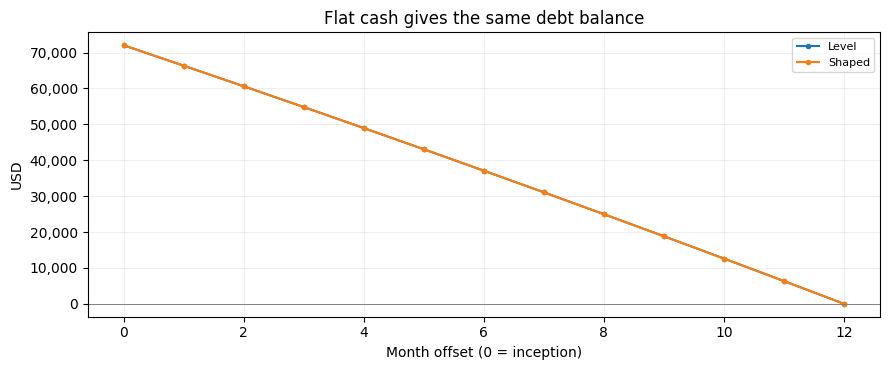

In [5]:
shaped = shape_debt_service(
    cfads_usd=cfads, minimum_dscr=1.25, nominal_annual_interest_rate=0.12
)
show_finance_table(
    ["Method", "Capacity (USD)", "Minimum DSCR"],
    [
        [
            "Level",
            capacity,
            min(
                debt_service_coverage(
                    cfads_usd=8_000,
                    debt_service_usd=r.interest_usd + r.principal_repayment_usd,
                )
                for r in loan[1:]
            ),
        ],
        ["Shaped", shaped.capacity_usd, shaped.minimum_defined_dscr],
    ],
)
display(
    plot_finance_series(
        {
            "Level": [r.closing_debt_usd for r in loan],
            "Shaped": [r.closing_debt_usd for r in shaped.rows],
        },
        title="Flat cash gives the same debt balance",
    )
)


def capacity_explorer(values, cash=cfads):
    from liquid_compute.financing import (
        build_amortizing_loan_schedule,
        level_payment_debt_capacity_usd,
        shape_debt_service,
    )

    inputs = dict(
        cfads_usd=cash,
        minimum_dscr=values["Minimum DSCR"],
        nominal_annual_interest_rate=values["Nominal annual rate"],
    )
    level = level_payment_debt_capacity_usd(**inputs)
    debt = build_amortizing_loan_schedule(
        principal_usd=level,
        nominal_annual_interest_rate=values["Nominal annual rate"],
        loan_term_months=len(cash),
    )
    shaped_case = shape_debt_service(**inputs)
    if not shaped_case.feasible:
        raise ValueError(shaped_case.reason)
    return {
        "Level debt": [r.closing_debt_usd for r in debt],
        "Shaped debt": [r.closing_debt_usd for r in shaped_case.rows],
    }


explore_finance_series(
    {"Minimum DSCR": minimum_dscr, "Nominal annual rate": nominal_annual_interest_rate},
    capacity_explorer,
    title="Coverage and rate determine debt capacity",
);

Both methods agree because every month looks the same. That agreement does not guarantee that customers will actually pay.

## Experiment 1 — The money comes later

Keep total yearly cash at USD 96,000. Now receive only USD 4,000 a month for the first six months and USD 12,000 a month for the next six.

The total is unchanged. But can the early, smaller amounts pay the loan on time?

In [6]:
uneven_cfads = (4_000,) * 6 + (12_000,) * 6
uneven_level, uneven_loan = size_level(uneven_cfads)
uneven_shaped = shape_debt_service(
    cfads_usd=uneven_cfads, minimum_dscr=1.25, nominal_annual_interest_rate=0.12
)
show_finance_table(
    ["Method", "Capacity (USD)", "Status"],
    [
        ["Uneven level", uneven_level, "Payment limited to USD 3,200"],
        ["Uneven shaped", uneven_shaped.capacity_usd, uneven_shaped.reason],
    ],
)

| Method | Capacity (USD) | Status |
| --- | --- | --- |
| Uneven level | 36,016.25 | Payment limited to USD 3,200 |
| Uneven shaped | 70,957.69 | All periods cover interest without capitalization |

An equal payment can now be only **USD 3,200**. That is half the old payment, so it supports half the old loan.

Shaped payments allow more borrowing than equal payments here. They ask for less early and more later, while keeping the 1.25 cushion and covering interest each month.

The lesson: **when money arrives matters, even when the total stays the same.**

## Experiment 2 — Require more repayment coverage

Return to USD 8,000 each month. Require USD 1.50 of cash for each USD 1 of loan payment instead of USD 1.25. This is another hypothetical lending rule.

In [7]:
tighter_capacity, tighter_loan = size_level(cfads, coverage=1.50)
show_finance_table(
    ["Coverage target", "Capacity (USD)", "Monthly payment (USD)"],
    [[1.25, capacity, 8_000 / 1.25], [1.50, tighter_capacity, 8_000 / 1.50]],
)

| Coverage target | Capacity (USD) | Monthly payment (USD) |
| --- | --- | --- |
| 1.25 | 72,032.50 | 6,400.00 |
| 1.50 | 60,027.08 | 5,333.33 |

The allowed payment falls to **USD 5,333.33** a month. The loan size falls in the same proportion.

A higher coverage requirement leaves more cash after scheduled repayments, providing room for weaker performance. With operating cash unchanged, that protection comes from reducing the permitted loan payment.

## Experiment 3 — No money in the first month

Now the first month brings zero cash. Each of the next 11 months brings USD 8,000.

Interest is still due in the first month. Counting the later cash alone could suggest a positive loan amount. That amount would still fail the first month’s interest requirement under the stated rules.

In [8]:
weak = (0,) + (8_000,) * 11
weak_shape = shape_debt_service(
    cfads_usd=weak, minimum_dscr=1.25, nominal_annual_interest_rate=0.12
)
show_finance_table(
    ["Measure", "Value"],
    [
        ["Level capacity (USD)", size_level(weak)[0]],
        ["Candidate shaped PV (USD; infeasible)", weak_shape.candidate_capacity_usd],
        ["Supported shaped capacity (USD)", weak_shape.capacity_usd],
        ["Reason", weak_shape.reason],
        [
            "Coverage with no debt service",
            debt_service_coverage(cfads_usd=0, debt_service_usd=0),
        ],
    ],
)

| Measure | Value |
| --- | --- |
| Level capacity (USD) | 0.00 |
| Candidate shaped PV (USD; infeasible) | 65,695.86 |
| Supported shaped capacity (USD) | 0.00 |
| Reason | Month 1 service is below interest; capitalization is excluded |
| Coverage with no debt service | N/A |

Both methods support **zero borrowing** in this case. Later cash cannot fix an unpaid bill today unless the loan rules change.

A payment holiday or later loan draw could change the result, but neither is included in these loan terms.

When no loan payment is due, coverage is shown as **N/A**, meaning “not applicable.” It is not an infinite safety cushion. Months with cash below zero also need a separate plan to pay bills; this simple loan-sizing method expects nonnegative cash.

F4 asks how much operating cash can repay. F5 asks how to pay for equipment before operations start. F6 asks how much a lender allows against eligible unpaid invoices. Those are different questions.

In [9]:
show_finance_table(
    ["Case", "Supported debt (USD)"],
    [
        ["Flat cash, 1.25x", capacity],
        ["Uneven, level", uneven_level],
        ["Uneven, shaped", uneven_shaped.capacity_usd],
        ["Flat cash, 1.50x", tighter_capacity],
        ["Weak first month, no capitalization", weak_shape.capacity_usd],
    ],
)

| Case | Supported debt (USD) |
| --- | --- |
| Flat cash, 1.25x | 72,032.50 |
| Uneven, level | 36,016.25 |
| Uneven, shaped | 70,957.69 |
| Flat cash, 1.50x | 60,027.08 |
| Weak first month, no capitalization | 0.00 |

## Next — Pay for the equipment before it earns money

Continue to **F5: Deployment and staged funding**.

The [World Bank's project-finance discussion](https://ppp.worldbank.org/financing/issues-in-project-financed-transactions) explains comparing available cash with interest and principal payments. Our cushion, dates and rule against adding unpaid interest to debt are hypothetical choices. The result is an example loan limit, not a market price or an actual loan offer.